# Heteroskedastic DNN Training

In [17]:
import tensorflow as tf
from tensorflow import keras    
from sklearn.preprocessing import StandardScaler
from scipy import stats
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import root_mean_squared_error, r2_score
from ML_Models.heteroscedastic_DNN import HeteroscedasticDNN
import numpy as np
import os
import csv
import random


##  Preprocessing

In [18]:
n4_df = pd.read_excel("../../data/boron_coord_final.xlsx")
n4_df = n4_df.dropna(subset='%')


In [19]:
other = ['Cr2O3', 'HfO2', 'PbO', 'UO3', 'Y2O3','ZrO2','Fe2O3',
         'P2O5', 'TiO2', 'CoO','SrO','Cs2O','Bi2O3','BaO','SO3','La2O3']
oxEl = ['Al2O3','B2O3','CaO','K2O','Li2O','MgO','Na2O','SiO2',
 'ZnO','Rb2O']


In [20]:
n4_df['other'] = n4_df[['Cr2O3', 'HfO2', 'PbO', 'UO3', 'Y2O3','ZrO2','Fe2O3','P2O5', 'TiO2', 'CoO','SrO','Cs2O','Bi2O3','BaO','SO3','La2O3']].sum(axis=1)
class_cols = oxEl + ['other']
X = n4_df[ class_cols ].fillna(0)
y = n4_df['%']


In [26]:
X_train_df, X_test_df, y_train_df, y_test_df = train_test_split(X, y, test_size=0.20, random_state=42)

X_train = X_train_df.to_numpy()
X_test = X_test_df.to_numpy()

y_train = y_train_df.to_numpy().reshape(-1,1)
y_test = y_test_df.to_numpy().reshape(-1,1)

## KFold Cross Validation

In [27]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [28]:
filename = 'dnn_architecture_tuning.csv'

if not os.path.exists(f'./{filename}'):
    with open(filename, 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames = ['arch', 'r2', 'rmse'])
        writer.writeheader()

    archs = [[8,8,8,8], [32,32,32,32], [32, 200, 200, 256]]
    for arch in archs: 
        r2 = []
        rmse = []
      
        for fold_idx, (train_index, test_index) in enumerate(kf.split(X_train, y_train)):
            X_ktrain = X_train[train_index]
            X_ktest = X_train[test_index]

            y_ktrain = y_train[train_index]
            y_ktest = y_train[test_index]
            
            model = HeteroscedasticDNN(input_dim=X_ktrain.shape[1], output_dim=y_ktrain.shape[1], hidden_layers=arch)
            history = model.fit(X_ktrain, y_ktrain)

            y_pred, var_pred = model.predict_with_uncertainty(X_ktest)
            y_pred = np.maximum(y_pred, 0)
            
            r2_k = r2_score(y_ktest, y_pred)
            rmse_k = root_mean_squared_error(y_ktest, y_pred)

            r2.append(r2_k)
            rmse.append(rmse_k)

            dict = {'arch': arch,
            'r2': r2_k,
            'rmse': rmse_k}

            with open(filename, 'a', newline='') as file:
                writer = csv.DictWriter(file, fieldnames = dict.keys())
                writer.writerow(dict)

        dict = {'arch': f'{arch}_average',
                'r2': sum(r2)/len(r2),
                'rmse': sum(rmse)/len(rmse)}
        
        with open(filename, 'a', newline='') as file:
            writer = csv.DictWriter(file, fieldnames = dict.keys())
            writer.writerow(dict)

In [29]:
# Define the filename for architecture tuning results
filename = 'dnn_architecture_tuning.csv'

print("\nSELECTING BEST ARCHITECTURE FROM TUNING RESULTS:")

try:
    # Step 1: Read the CSV file
    df = pd.read_csv(filename)

    # Step 2: Filter rows where architectures are NOT averages (you can include averages or exclude them)
    df_filtered = df[df["arch"].astype(str).str.contains('average')]
    
    # Step 3: Define the performance metric for selecting the best architecture
    best_row = df_filtered.loc[df_filtered['r2'].idxmax()]  # Choose row with the highest accuracy
    # Alternatively, minimize RMSE:
    # best_row = df_filtered.loc[df_filtered['rmse'].idxmin()] 
    
    # Save best architecture for the model
    best_architecture = best_row['arch'].replace('_average','')  # Extract the architecture
    
    # Extract performance metrics
    best_r2 = best_row['r2']
    best_rmse = best_row['rmse']
    
    # Print the best architecture and performance metrics
    print("Best Architecture:")
    print(f"  Architecture: {best_architecture}")
    print("Performance:")
    print(f"  R²: {best_r2}")
    print(f"  RMSE: {best_rmse}")

except Exception as e:
    # Handle errors gracefully
    print(f"Error processing architecture tuning results: {str(e)}")


SELECTING BEST ARCHITECTURE FROM TUNING RESULTS:
Best Architecture:
  Architecture: [32, 200, 200, 256]
Performance:
  R²: 0.9320413529053572
  RMSE: 5.567567857899153


## Train Model

In [33]:
# Initialize and train model
model = HeteroscedasticDNN(input_dim=X_train.shape[1], output_dim=1, hidden_layers=[32, 200, 200, 256])
history = model.fit(X_train, y_train)

Epoch 1/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5803 - learning_rate: 0.0010
Epoch 2/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5154 - learning_rate: 0.0010
Epoch 3/5000
 1/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.4607

c:\Users\curr666\AppData\Local\miniconda3\envs\nepheline\lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)
c:\Users\curr666\AppData\Local\miniconda3\envs\nepheline\lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5133 - learning_rate: 0.0010
Epoch 4/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5063 - learning_rate: 0.0010
Epoch 5/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4988 - learning_rate: 0.0010
Epoch 6/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4803 - learning_rate: 0.0010
Epoch 7/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4238 - learning_rate: 0.0010
Epoch 8/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2850 - learning_rate: 0.0010
Epoch 9/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1958 - learning_rate: 0.0010
Epoch 10/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1476 - learning_rate: 0.0010
Epoch 11/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1241 - learning_rate: 0.0010
Epoch 12/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1023 - learning_rate: 0.0010
Epoch 13/5000
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0923 - learning_rate: 0.0010
Epoch 14

## Evaluate Test Data

In [34]:
# Make predictions with uncertainty
mean_pred, std_pred = model.predict_with_uncertainty(X_test)

# Calculate confidence intervals
confidence_95 = 1.96 * std_pred
lower_bound = mean_pred - confidence_95
upper_bound = mean_pred + confidence_95

In [36]:

rmse = root_mean_squared_error(y_test, mean_pred)

r2 = r2_score(y_test, mean_pred)

print(rmse)
print(r2)

7.26166073885951
0.8870847291043171


In [37]:
y_train_pred, train_var = model.predict_with_uncertainty(X_train)


## Save Model and Results

In [38]:
train_df = pd.DataFrame({
    'y_true': y_train.flatten(),
    'y_pred': y_train_pred.flatten(),
    'var_pred': train_var.flatten(),
    'is_train': 1
}, index=y_train_df.index)

test_df = pd.DataFrame({
    'y_true': y_test.flatten(),
    'y_pred': mean_pred.flatten(),
    'var_pred': std_pred.flatten(),
    'is_train': 0
}, index=y_test_df.index)

results = pd.concat([train_df, test_df])

full_results = n4_df['Glass Name'].to_frame().join(results, how='left')

full_results.to_csv('../results/regression/DNN_with_cr_results.csv')

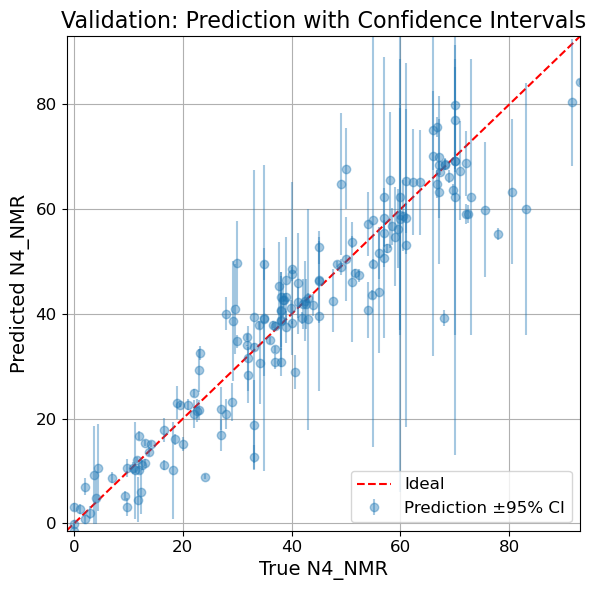

In [39]:
import matplotlib.pyplot as plt

# Flatten arrays for plotting
y_true = y_test.flatten()
y_pred = mean_pred.flatten()
y_std = std_pred.flatten()

# Set axis limits to the same range
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

# Confidence intervals (z-scores for normal distribution)
conf_levels = {
    # "80%": 1.28,
    # "90%": 1.645,
    "95%": 1.96
}

plt.figure(figsize=(6, 6))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')

# Plot predictions with error bars for each confidence interval
for label, z in conf_levels.items():
    plt.errorbar(
        y_true, y_pred, yerr=z * y_std,
        fmt='o', alpha=0.4, label=f'Prediction ±{label} CI'
    )

plt.xlabel('True N4_NMR', fontsize=14)
plt.ylabel('Predicted N4_NMR', fontsize=14)
plt.title('Validation: Prediction with Confidence Intervals', fontsize=16)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
# plt.xlim(-0.2, 1.0)
# plt.ylim(-0.2, 1.0)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()